**Código de la práctica de Cosmología 2025-26**

**Nombre:** Germán Cousillas Martínez

**DNI:** 79124779H

**Grupo:** L5

# Cuestión 1

## Apartado 1: Demostración de $H0dl$

- Véase informe

## Apartado 2: Cálculo numérico de $H0dl$

- Se pide consturir una función que estime la distancia por luminosidad a cierto redshift: $H_0d_L(z, \omega_0, \omega_a, \Omega_M)=(1+z)\int_0^z \frac{dx}{\sqrt{\Omega_M(1+x)^3 + \Omega_\Lambda (1+x)^{3(1+\omega_0+\omega_a)} e^{-3\omega_a x/(1+x)}}}$
- Por simplicidad, procedo de forma numérica con un black box de integración. Si se quisiera un mayor control sobre la rutina de integración y su correspondiente error, o si el integrando fuera patológico, convendría más definir nuestra propia rutina
- **Nota:** estrictamente, la práctica pide que la función H0dl admita un array de redshifts. No obstante, para una mayor optimización del código, defino la función para que acepte un único valor de redshift y posteriormente, en una línea, vectorizo convenientemente el argumento z de una forma distinta a cómo lo hace Numpy, porque el método np.vectorize() es un wrapper y no mejora la eficiencia del código

In [2]:
import scipy.integrate as integrate
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, '$H0d_L$')

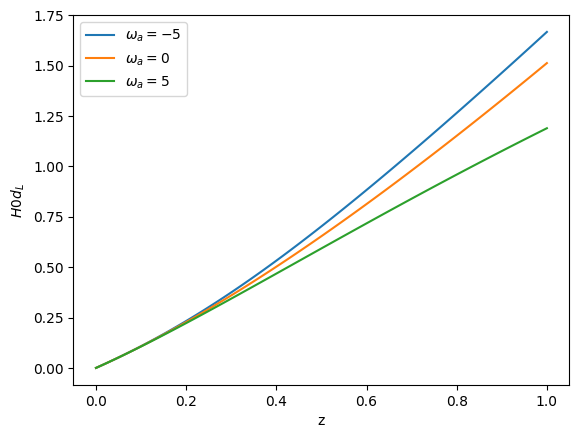

In [3]:
def H0dl(z, w0, wa, OmegaM=0.334):
    OmegaDE = 1-OmegaM # Regla de suma cósmica
    integrand = lambda x: 1/np.sqrt(OmegaM*(1+x)**3 + OmegaDE*(1+x)**(3 * (1+w0+wa)) * np.exp(-3*wa*x/(1+x)))
    return (1+z)*integrate.quad(integrand, 0, z)[0]

# Plotting:
z = np.linspace(0, 1, 100)

# wa = -5, 0, 5
y1 = [H0dl(val, -1, -5) for val in z]
y2 = [H0dl(val, -1, 0) for val in z]
y3 = [H0dl(val, -1, 5) for val in z]

plt.plot(z, y1, label="$\\omega_a=-5$")
plt.plot(z, y2, label="$\\omega_a=0$")
plt.plot(z, y3, label="$\\omega_a=5$")
plt.legend()
plt.xlabel("z")
plt.ylabel("$H0d_L$")

- Se pide también evaluar $H0dl$ para $(z, \omega_0, \omega_a)=(0.2, -1, 5)$

In [4]:
print(H0dl(0.2, -1, 5))

0.22240932187850732


## Apartado 3: cálculo de distancias

- Empleando nuestra relación $d_L(z)$, se pide ahora que usemos esta función para calcular el módulo de distancia $\mu^{th}(z)$, como es costumbre en Astrofísica observacionl, como la diferencia de las magnitudes aparente y absoluta de un objeto luminoso a cierto redshift:

$$\mu^{th}(z, h, \omega_0, \omega_a, \Omega_M)=5\log_{10}\left(\frac{d_L}{Mpc}\right)+25$$

**Nota:** véase que la constante de Hubble forma parte de un modelo cosmológico, de modo que, estrictamente, debe entrar en los parámetros de nuestras funciones, que obviamente son dependientes del modelo seleccionado

In [5]:
def muth(z, h, w0, wa, OmegaM=0.334):
    H0_1 = 2997.9/h # [Mpc]
    dl = H0_1*H0dl(z, w0, wa, OmegaM)
    return 5*np.log10(dl) + 25

- Se pide evaluar el módulo de la distancia enn $(z, h, \omega_0, \omega_a)=(0.2, 0.7, -1, 5)$

In [6]:
print(muth(0.2, 0.7, -1, 5))

39.89436044031914


# Cuestión 2

## Apartado 1: cargando datos

In [7]:
zobs, muobs = np.loadtxt("PantheonSH0ES_unique_data.txt",
skiprows=1, unpack=True)

cov = np.loadtxt("PantheonSH0ES_unique_cov.gz")
cov_1 = np.linalg.inv(cov)

## Apartado 2: construyendo $\chi^2$

- Construimos $\chi^2 = \Delta^T C^{-1}\Delta$ con $\Delta_i = \mu^{obs}_i-\mu^{th}_{i}$

In [8]:
def chi2(h, w0, wa, OmegaM=0.334):
    Delta = np.array(list(map(lambda z: muth(z, h, w0, wa, OmegaM), zobs))) - muobs
    return np.dot(Delta, np.matmul(cov_1, Delta))

## Apartado 3: evaluación de prueba

- Finalmente, evaluamos en el punto $(h, \omega_0, \omega_a)=(0.65, -1, 5)$

In [9]:
print(chi2(0.65, -1, 5))

2991.885694980012


# Cuestión 3.1

## Apartado 1: Ajuste de $\omega_0$

- Procedo a ajustar el modelo que hemos construido dejando libre únicamente $\omega_0$, fijando los demás parámetros del modelo como sigue: $(h, \omega_a, \Omega_M)=(0.73, 0, 0.334)$

In [10]:
from scipy.optimize import minimize

chi2_constr = lambda w0: chi2(0.7304, w0, 0)
w0_init = -1 # Mi valor inicial de w0 será evidentemente el que da el modelo estándar

w0_best = minimize(chi2_constr, w0_init, method="Nelder-Mead", tol=1e-6) # -0.9926

In [11]:
print(f"Best w0: {str(w0_best.x)}")
print(f"chi2(w0_best) = {w0_best.fun}")

Best w0: [-0.99262466]
chi2(w0_best) = 1135.4781194603916


**Nota:** observamos que, efectivamente, el valor que obtenemos es muy cercano a lo que predice $\Lambda CDM$

## Apartado 2: cálculo de errores a $1\sigma$

- Del guión sabemos que $\omega_0$ a una sigma estará en aquel intervalo de que cumpla: $\Delta \chi^2=1$, donde $\Delta \chi^2=\chi^2(\omega_0, \ldots)-\chi^2_{min}$

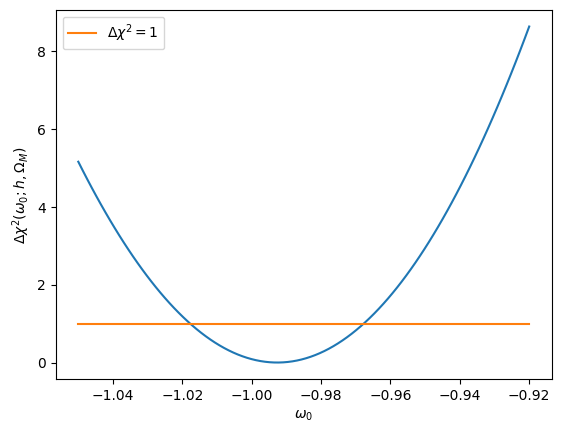

In [16]:
from scipy.optimize import bisect

DeltaChi2 = lambda w0: chi2_constr(w0) - w0_best.fun

x = np.linspace(-1.05, -1+0.08, 100)
plt.xlabel("$\\omega_0$")
plt.ylabel("$\\Delta \\chi^2(\\omega_0; h, \\Omega_M)$")
plt.plot(x, [DeltaChi2(val) for val in x])
plt.plot(x, np.ones_like(x), label="$\\Delta\\chi^2=1$")
plt.legend()
#plt.savefig("a.png")

**Nota:** para hallar aquellos valores de $\omega_0$ donde $\Delta\chi^2=1$, podemos hallar las raíces de $\Delta\chi^2-1=0$

In [12]:
f = lambda w0: DeltaChi2(w0)-1

root_right = bisect(f, -0.98, -0.94)
root_left = bisect(f, -1.04, -1)

In [13]:
print(f"Root right: {root_right}")
print(f"Root left: {root_left}")

Root right: -0.9677101687958929
Root left: -1.01774871214875


In [14]:
err_right = root_right - w0_best.x
err_left = w0_best.x - root_left

print(err_right, err_left)

[0.0249145] [0.02512405]


**Resultado:**

$$\boxed{\omega_0=-0.993^{+0.025}_{-0.025} = -0.993 \pm 0.025}$$

## Apartado 3: Comparación con Planck 2018

- Véase informe

## Apartado 4: comparación del ajuste teórico y del ajuste con Planck 2018 con los datos observados

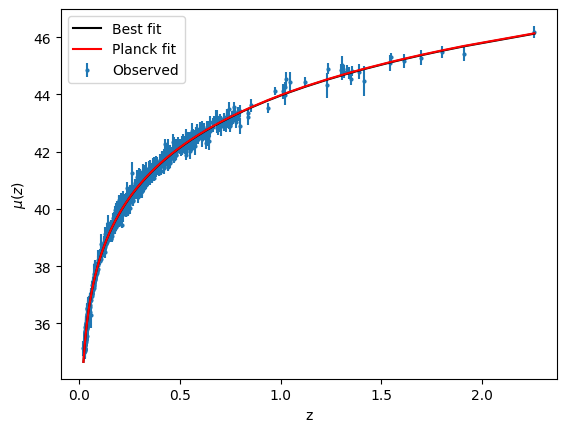

In [18]:
plt.errorbar(zobs, muobs, yerr=[np.sqrt(cov[i,i]) for i in range(len(zobs))], fmt="o", markersize=2, label="Observed", zorder=1)
plt.plot(zobs, list(map(lambda z: muth(z, 0.7304, w0_best.x, 0), zobs)), "k-", label="Best fit", zorder=2) # w0 best
plt.plot(zobs, list(map(lambda z: muth(z, 0.7304, -1.028, 0), zobs)), "r-", label="Planck fit", zorder=3) # w0 Planck
plt.xlabel("z")
plt.ylabel("$\\mu(z)$")
plt.legend()
#plt.savefig("comparison.png")

## Apartado 5

- Se pide finalmente calcular la distancia por luminosidad y la distancia comóvil a un objeto situado a $z=0.4$ para nuestro modelo con $\omega_0$ ajustado a los datos de supernovas

### Distancia por luminosidad

- Tenemos programado $H_0d_L$, así que basta con multiplicar por $H_0^{-1}=2997.9h^{-1}$, donde elijo $h=0.7304$

In [19]:
d_L = H0dl(0.4, w0_best.x, 0)*2997.9/(0.7304)

print(f"Distancia por luminosidad: {d_L} [Mpc]")

Distancia por luminosidad: 2060.031703769468 [Mpc]


### Distancia comóvil

- Calculamos ahora la distancia comóvil a la supernova. Véase que, si tenemos el factor de escala normalizado a 1 para hoy, dicha distancia coincidirá con la física (hoy). Para ello, admitimos que vivimos en un Universo plano, de modo que las distancias comóvil y transversa coinciden, así que $\chi(z)=r(z)=H_0^{-1}\int_0^z \frac{dx}{E(x)}$, es decir:

$$\chi(z)=\frac{d_L(z)}{1+z}$$

In [20]:
dist_comovil = d_L/(1+0.4)
print(f"Distancia comóvil: {dist_comovil} [Mpc]")

Distancia comóvil: 1471.4512169781915 [Mpc]


# Cuestión 3.2

- Procedemos ahora a dejar libres los valores de $\omega_0$ y de $h$. En una breve nota, diré que hay que tener cuidado con esto, porque como ahora tenemos dos parámetros en un mismo modelo, tenemos que vigilar que ninguno de ellos se "trague" física relativa al otro. Además, como tenemos dos parámetros pero un solo observable, debemos vigilar también que ninguno de los parámetros se convierta en un $\textit{nuisance parameter}$, ya que pretendemos resolver los dos. Por último, aunque supongo que queda fuera del scope de esta práctica, sería procedente realizar una breve evaluación sobre si tenemos suficiente sensibilidad en el modelo para resolver ambos parámetros con un error aceptable y, sobre todo, un goodness aceptable.

## Apartado 1: ajuste a $(h,\omega_0)$

- Procedo ahora al ajuste para dos parámetros
- En espíritu, el procedimiento es el mismo que cuando solo teníamos un parámetro, solo que ahora $\chi^2$ será una función en un espacio de dos variables. Por suerte, la función "minimize" de scipy permite minimizar funciones multivariable, de modo que los cambios de la implementación anterior serán mínimos
- Véase que, si no se pidiera representar las regiones del espacio de parámetros relativas a los correspondientes intervalos de confianza, podríamos emplear la función "curve_fit" y obtener el mismo resultado de forma mucho más directa

In [19]:
chi2_constr2 = lambda inp: chi2(inp[0], inp[1], 0)

init = [0.7, -1] # Fijo los valores a lo que ya sé que tiene que estar más o menos bien para que no tarde mucho

best = minimize(chi2_constr2, init, method="Nelder-Mead", tol=1e-6)

In [20]:
h_best_val = best.x[0]
w0_best_val = best.x[1]

In [21]:
print(f"Best h: {h_best_val}")
print(f"Best w0: {w0_best_val}")
print(f"chi2(h0_best, w0_best_val) = {best.fun}")

Best h: 0.7286497681760437
Best w0: -0.9679819084446487
chi2(h0_best, w0_best_val) = 1135.1735054921098


## Apartado 2: contornos

- Como ahora el espacio de parámetros es de dimensión superior a 1, ya no tiene sentido hablar de intervalos de confianza. En su lugar, tendremos regiones sobre el plano de los parámetros tales que los puntos dentro de dicha región se encuentren a menos de 1, 2 o 3 sigmas del mínimo de $\chi^2$

In [22]:
chi2_plot = lambda h, w0: chi2(h, w0, 0)

h_axis = np.linspace(0.718, 0.740, 30)
w0_axis = np.linspace(-1.16, -0.795, 30)

H, W0 = np.meshgrid(h_axis, w0_axis)

chi2_vect = np.vectorize(chi2_plot)

CHI2 = chi2_vect(H, W0)

In [23]:
DCHI2 = CHI2 - np.ones_like(CHI2)*best.fun

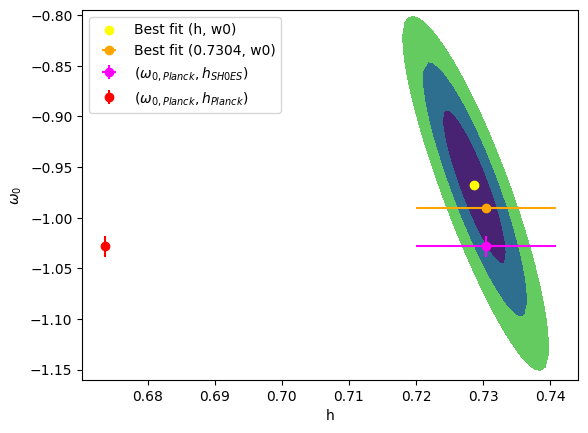

In [25]:
plt.contourf(H, W0, DCHI2, levels=[0, 2.3, 6.18, 11.83])

h_shoes_err = 1.04/100
w0_error = 0.032

# Best fit
plt.scatter(best.x[0], best.x[1], label="Best fit (h, w0)", color="yellow")
# w0 only
plt.errorbar(0.7304, -0.99, xerr=h_shoes_err, label="Best fit (0.7304, w0)", color="orange", fmt="o")
# Shoes
plt.errorbar(0.7304, -1.028, xerr=h_shoes_err, yerr=h_shoes_err, label="$(\\omega_{0, Planck}, h_{SH0ES})$", color="magenta", fmt="o")
# Planck
plt.errorbar(0.6736, -1.028, yerr=h_shoes_err, label="$(\\omega_{0, Planck}, h_{Planck})$", color="red", fmt="o")
plt.legend(loc="upper left")
plt.xlabel("h")
plt.ylabel("$\\omega_0$")
plt.savefig("hw0.png")

## Apartado 3: estimación de errores a $1\sigma$

Como se dice en el informe, introduzcamos la elipse de $1\sigma$ en un rectángulo para dar una estimación conservadora del error de cada parámetro

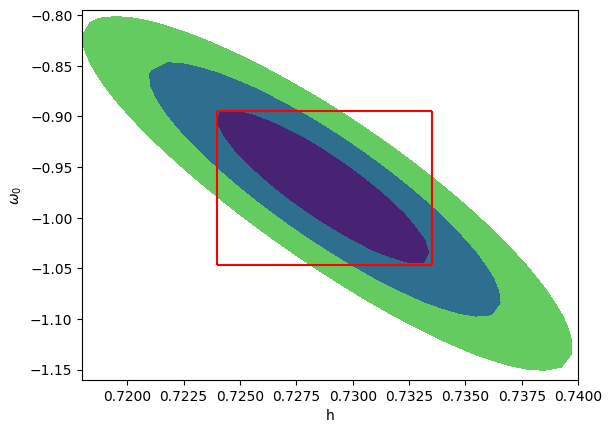

In [64]:
plt.contourf(H, W0, DCHI2, levels=[0, 2.3, 6.18, 11.83])


# Rectángulo
plt.hlines(-0.895, color="r", xmin=0.7240, xmax=0.7335)
plt.hlines(-1.047, color="r", xmin=0.7240, xmax=0.7335)
plt.vlines(0.7240, color="r", ymin=-1.047, ymax=-0.895)
plt.vlines(0.7335, color="r", ymin=-1.047, ymax=-0.895)
plt.xlabel("h")
plt.ylabel("$\\omega_0$")
plt.savefig("enmarcado.png")

Ahora ya podemos determinar la cota superior al error de cada parámetro del ajuste como la diferencia entre el valor de mejor ajuste y el máximo / mínimo de la elipse a $1\sigma$

In [74]:
hmin = 0.7240
hmax = 0.7335

err_Lh = np.abs(best.x[0]-hmin)
err_Rh = np.abs(best.x[0]-hmax)

w0min = -1.047
w0max = -0.895

err_Lw0 = np.abs(best.x[1]-w0min)
err_Rw0 = np.abs(best.x[1]-w0max)

print(f"h={best.x[0]} (+{err_Rh})(-{err_Lh})")
print(f"w0={best.x[1]} (+{err_Rw0})(-{err_Lw0})")

h=0.7286497681760437 (+0.004850231823956386)(-0.004649768176043678)
w0=-0.9679819084446487 (+0.07298190844464869)(-0.07901809155535122)


$$\boxed{h=0.72865^{+0.0049}_{-0.0046}}$$

$$\boxed{\omega_0=-0.968^{+0.073}_{-0.079}}$$

**Nota:** para una discusión sobre por qué el error en $h$ de SH0ES+Planck es tan grande en comparación con el de Planck 2018, véase informe

## Apartado 4: compatibilidad con Universo en expansión

- Véase informe

# Cuestión 3.3

## Apartado 1: expresión analítica de $h$ marginalizado

La expresión de $h$ tal que minimiza $\chi^2$ para cada par $(\omega_0,\omega_a)$ es:

$$log_{10}(h_m) = -\frac{1}{5}\frac{\vec 1^T C^{-1}\left[\vec \mu_{obs}-25\cdot \vec1-5\log_{10}\left(2997.9H_0\vec d_L\right)\right]\vec 1}{\vec 1^TC^{-1}\vec 1}$$

In [34]:
ones = np.ones(len(cov_1))
S = np.sum(cov_1)

def log10_hm(w0, wa):
    A = muobs - 25*ones - 5*np.log10(list(map(lambda x: 2997.9*H0dl(x, w0, wa), zobs)))
    return -np.matmul(ones.T, np.matmul(cov_1, A))/(5*S)

hm = lambda w0, wa : 10**log10_hm(w0, wa)

Se nos pide evaluar $h(-1, -3)$:

In [35]:
hm(-1, -3)

np.float64(0.7430415465887373)

**Nota:** como es de esperar, si evaluamos en los valores de $\Lambda$CDM, obtenemos el valor medido por Planck+SH0ES:

In [36]:
hm(-1,0)

np.float64(0.7303832779952965)

## Apartado 2: ajuste y contornos

In [83]:
chi2_constr2 = lambda inp: chi2(hm(inp[0], inp[1]), inp[0], inp[1])

init = [-1, 0] # Fijo los valores a lo que ya sé que tiene que estar más o menos bien para que no tarde mucho

best = minimize(chi2_constr2, init, method="Nelder-Mead", tol=1e-6)

In [84]:
w0_best_val = best.x[0]
wa_best_val = best.x[1]

In [85]:
print(f"Best w0: {w0_best_val}")
print(f"Best wa: {wa_best_val}")
print(f"chi2(w0_best, wa_best_val) = {best.fun}")

Best w0: -0.8831235715746569
Best wa: -0.5904783269010314
chi2(w0_best, wa_best_val) = 1134.5854259793207


In [87]:
chi2_plot = lambda w0, wa: chi2(hm(w0,wa), w0, wa)

w0_axis = np.linspace(-1.32, -0.46, 30)
wa_axis = np.linspace(-3.5, 1.95, 30)

W0, WA = np.meshgrid(w0_axis, wa_axis)

chi2_vect = np.vectorize(chi2_plot)

CHI2 = chi2_vect(W0, WA)

In [88]:
DCHI2 = CHI2 - np.ones_like(CHI2)*best.fun

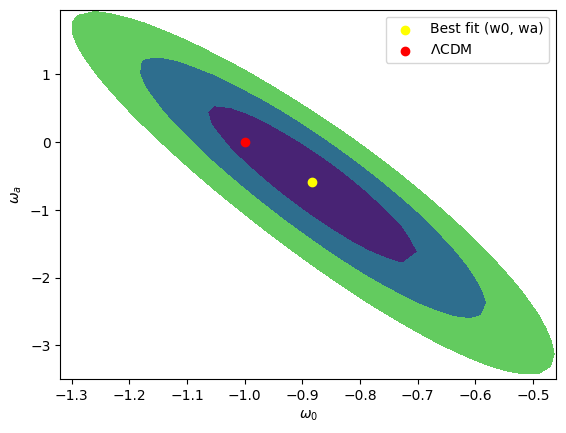

In [91]:
plt.contourf(W0, WA, DCHI2, levels=[0, 2.3, 6.18, 11.83])

# Best fit
plt.scatter(best.x[0], best.x[1], label="Best fit (w0, wa)", color="yellow")
# LCDM
plt.scatter(-1, 0, label="$\\Lambda$CDM", color="red")

plt.legend(loc="upper right")
plt.xlabel("$\\omega_0$")
plt.ylabel("$\\omega_a$")
plt.savefig("marginalized.png")

## Apartados 3 y 4:

- Véase informe